In [46]:
# Damit Pfadobjekte erzeugt werden
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [47]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [48]:
pfad_rohdaten = Path("../data/raw")
print(pfad_rohdaten.resolve()) #zeigt vollständigen Pfad an

/Users/koppanymolnar/Documents/Projekt-Timeseries/industrial-ai-timeseries/data/raw


In [49]:
# Druckwerte in Bar

ps1 = pd.read_csv(
    pfad_rohdaten / "PS1.txt",
    sep = r"\s+", # Separator, mehrere Leerzeichen
    header = None,
)

# Temperaturwerte in Grad Celsius

ts1 = pd.read_csv(
    pfad_rohdaten / "TS1.txt",
    sep = r"\s+",
    header = None,
)

# Volumenstrom in Litern pro Minute

fs1 = pd.read_csv(
    pfad_rohdaten / "FS1.txt",
    sep = r"\s+",
    header = None,
)

# Vibrationsgeschwindigkeit in Millimetern pro Sekunde

vs1 = pd.read_csv(
    pfad_rohdaten / "VS1.txt",
    sep = r"\s+",
    header = None,
)

# Zustandsklassen

profile = pd.read_csv(
    pfad_rohdaten / "profile.txt",
    sep = r"\s+",
    header = None,
)

##### Zeilen <=> Maschinenzyklen
##### Spalten <=> Werte innerhalb eines Maschinenzyklus

In [54]:
print("PS1: ", ps1.shape)
print("TS1: ", ts1.shape)
print("FS1: ", fs1.shape)
print("VS1: ", vs1.shape)
print("Profile: ", profile.shape)

PS1:  (2205, 6000)
TS1:  (2205, 60)
FS1:  (2205, 600)
VS1:  (2205, 60)
Profile:  (2205, 5)


In [55]:
profile.columns = [
    "cooler_condition",
    "valve_condition",
    "internal_pump_leakage",
    "hydraulic_accumulator",
    "stable_flag",
]

profile.head()

,cooler_condition,valve_condition,internal_pump_leakage,hydraulic_accumulator,stable_flag
0,3,100,0,130,1
1,3,100,0,130,1
2,3,100,0,130,1
3,3,100,0,130,1
4,3,100,0,130,1


##### Das sind die Zustände für die 2205 Zyklen, die Labels für jeden Maschinenzyklus.

##### cooler_condition beschreibt die Leistungsfähigkeit des Kühlers. 3 <=> nahezu vollständiger Ausfall, 20 <=> verringerte Kühlleistung und 100 <=> volle Kühlleistung.

##### valve_condiditon beschreibt das Schaltverhalten des Ventils. 73 <=> nahezu vollständiger Ausfall, 80 <=> starke Verzögerung, 90 <=> geringe Verzögerung und 100 <=> optimales Schaltverhalten.

##### internal_pump_leakage beschreibt die Stärke einer internen Leckage in der Pumpe. 0 <=> keine Leckage, 1 <=> geringe Leckage und 2 <=> starke Leckage.

##### hydraulic_accumulator beschreibt den Gasvordruck des Hydraulikspeichers in bar. 90 <=> stark verringerter Druck, 100 <=> deutlich verringerter Druck, 115 <=> leicht verringerter Druck und 130 <=> optimaler Druck.

##### stable_flag beschreibt ob der Maschinenzyklus unter stabilen Bedingungen aufgenommen wurde. 0 <=> ,,Bedingungen waren stabil." und 1 <=> ,,Stabiler Zustand wurde möglicherweise noch nicht erreicht."


##### Wir haben für jeden Zyklus die Sensordaten PS1, TS1, FS1 und VS1. Wir haben zusätzlich aber auch für jeden Zyklus die Zustände der Maschine (profile) wie cooler_condition usw.

In [56]:
profile["cooler_condition"].value_counts().sort_index()

cooler_condition
3      732
20     732
100    741
Name: count, dtype: int64

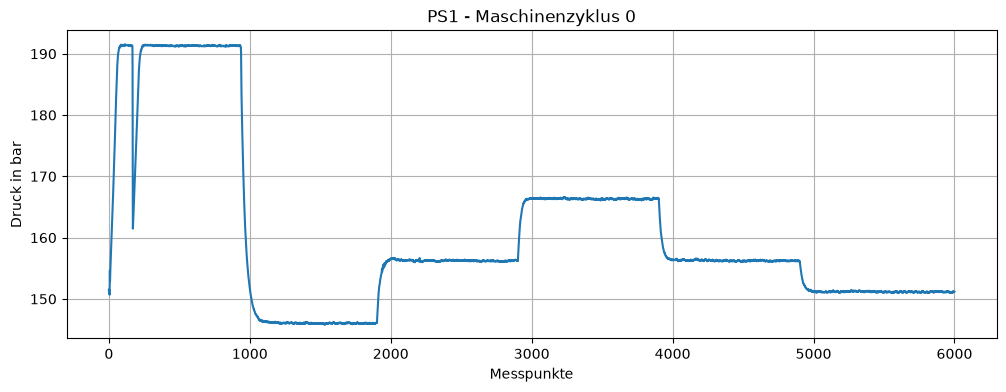

In [57]:
i = 0

plt.figure(figsize = (12,4))
plt.plot(ps1.iloc[i].to_numpy())
plt.xlabel("Messpunkte")
plt.ylabel("Druck in bar")
plt.title(f"PS1 - Maschinenzyklus {i}")
plt.grid()
plt.show()

In [58]:
cooler3ListeIndizes = profile.index[profile["cooler_condition"] == 3].to_list()
print(cooler3ListeIndizes)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

##### Vergleichsplot erstellen:

In [59]:
cooler3First = profile.index[profile["cooler_condition"] == 3][0]
cooler20First = profile.index[profile["cooler_condition"] == 20][0]
cooler100First = profile.index[profile["cooler_condition"] == 100][0]

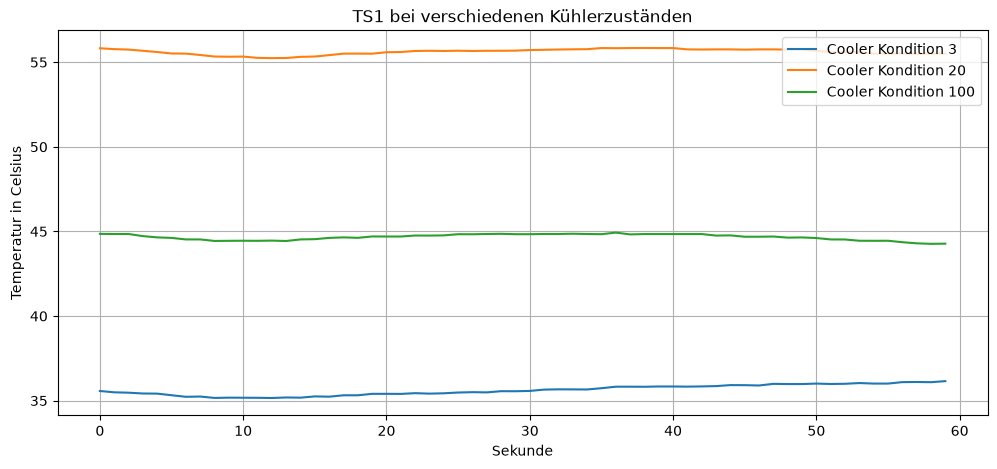

In [60]:
plt.figure(figsize=(12, 5))

plt.plot(
    ts1.iloc[cooler3First].to_numpy(),
    label = "Cooler Kondition 3"
)

plt.plot(
    ts1.iloc[cooler20First].to_numpy(),
    label = "Cooler Kondition 20"
)

plt.plot(
    ts1.iloc[cooler100First].to_numpy(),
    label = "Cooler Kondition 100"
)

plt.xlabel("Sekunde")
plt.ylabel("Temperatur in Celsius")
plt.title("TS1 bei verschiedenen Kühlerzuständen")
plt.legend()
plt.grid()
plt.show()

In [61]:
cooler3Liste = profile.index[profile["cooler_condition"] == 3].to_list()
cooler20Liste = profile.index[profile["cooler_condition"] == 20].to_list()
cooler100Liste = profile.index[profile["cooler_condition"] == 100].to_list()

In [70]:
ts1Cooler3DF = ts1.iloc[cooler3Liste]
# print(ts1Cooler3.to_string())

In [67]:
ts1Cooler20DF = ts1.iloc[cooler20Liste]
ts1Cooler100DF = ts1.iloc[cooler100Liste]

##### Holen jetzt die Durchschnittswerte der Features aus den 3 DataFrames (60 Werte jeweils):

In [71]:
ts1Mean3DF = ts1Cooler3DF.mean(axis = 0) # spaltenweise, Durchschnitt über alle Zyklen pro Sekunde
ts1Mean20DF = ts1Cooler20DF.mean(axis = 0)
ts1Mean100DF = ts1Cooler100DF.mean(axis = 0)

<function matplotlib.pyplot.show(close=None, block=None)>

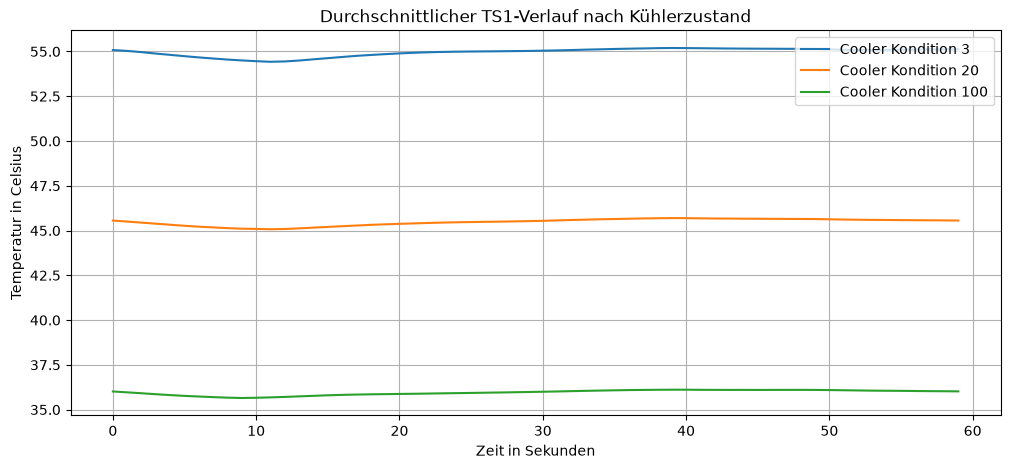

In [76]:
plt.figure(figsize = (12, 5))

plt.plot(
    ts1Mean3DF.to_numpy(),
    label = "Cooler Kondition 3"
)

plt.plot(
    ts1Mean20DF.to_numpy(),
    label = "Cooler Kondition 20"
)

plt.plot(
    ts1Mean100DF.to_numpy(),
    label = "Cooler Kondition 100"
)

plt.xlabel("Zeit in Sekunden")
plt.ylabel("Temperatur in Celsius")
plt.title("Durchschnittlicher TS1-Verlauf nach Kühlerzustand")
plt.legend()
plt.grid()
plt.show()